# Brain tumor 3D segmentation with MONAI

This notebook performs multi-label 3D segmentation of brain tumors using the BraTS2020 dataset. It loads NIfTI volumes directly and trains a 3D U-Net model.

Features:
1. Direct NIfTI volume loading via MONAI transforms.
1. Patient-level train/validation split (80/20) from training data.
1. 3D random cropping with positive/negative sampling.
1. 3D U-Net model with Dice loss and sliding-window inference.
1. Deterministic training for reproducibility.

**Tumor sub-regions:**
- **TC** (Tumor Core): union of GD-enhancing tumor and necrotic/non-enhancing core
- **WT** (Whole Tumor): union of TC and peritumoral edema
- **ET** (Enhancing Tumor): GD-enhancing tumor only

![image](../figures/brats_tasks.png)

## Setup environment

In [21]:
%matplotlib inline

## Setup imports

In [22]:
import os
import sys
import time
import glob
import multiprocessing as mp
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split

from monai.config import print_config
from monai.data import DataLoader, Dataset, decollate_batch, list_data_collate
from monai.inferers import sliding_window_inference
from monai.losses import DiceLoss
from monai.metrics import DiceMetric
from monai.networks.nets import UNet
from monai.transforms import (
    Activations,
    AsDiscrete,
    Compose,
    EnsureChannelFirstd,
    LoadImaged,
    NormalizeIntensityd,
    RandCropByPosNegLabeld,
    RandFlipd,
    RandScaleIntensityd,
    RandShiftIntensityd,
)
from monai.utils import set_determinism

import torch

# Use 'spawn' explicitly on macOS for safe multiprocessing
mp.set_start_method("spawn", force=True)

# Ensure src/ is importable so spawned workers can find custom transforms
_src_dir = os.path.normpath(os.path.join(os.getcwd(), ".."))
if _src_dir not in sys.path:
    sys.path.insert(0, _src_dir)

from datasets import ConvertToMultiChannelBasedOnBratsClassesd

print_config()

MONAI version: 1.5.2
Numpy version: 2.4.2
Pytorch version: 2.10.0
MONAI flags: HAS_EXT = False, USE_COMPILED = False, USE_META_DICT = False
MONAI rev id: d18565fb3e4fd8c556707f91ac280a2dc3f681c1
MONAI __file__: /Users/<username>/cogito/cancervision/.venv/lib/python3.13/site-packages/monai/__init__.py

Optional dependencies:
Pytorch Ignite version: NOT INSTALLED or UNKNOWN VERSION.
ITK version: NOT INSTALLED or UNKNOWN VERSION.
Nibabel version: 5.4.0
scikit-image version: NOT INSTALLED or UNKNOWN VERSION.
scipy version: 1.17.1
Pillow version: 12.1.1
Tensorboard version: NOT INSTALLED or UNKNOWN VERSION.
gdown version: NOT INSTALLED or UNKNOWN VERSION.
TorchVision version: 0.25.0
tqdm version: 4.67.3
lmdb version: NOT INSTALLED or UNKNOWN VERSION.
psutil version: 7.2.2
pandas version: NOT INSTALLED or UNKNOWN VERSION.
einops version: NOT INSTALLED or UNKNOWN VERSION.
transformers version: NOT INSTALLED or UNKNOWN VERSION.
mlflow version: NOT INSTALLED or UNKNOWN VERSION.
pynrrd version: 

## Setup data directory

Point to the local BraTS2020 NIfTI dataset. Each patient folder contains four MRI modalities (FLAIR, T1, T1ce, T2) as `.nii` volumes plus a segmentation mask.

The official validation set has no segmentation labels, so we split the training data 80/20 for training and metric evaluation.

In [23]:
data_dir = os.path.normpath(os.path.join(os.getcwd(), "..", "..", "res", "data", "archive"))
train_data_dir = os.path.join(data_dir, "BraTS2020_TrainingData", "MICCAI_BraTS2020_TrainingData")

print(f"Data directory: {train_data_dir}")
print(f"Exists: {os.path.isdir(train_data_dir)}")


def find_nifti(patient_dir, patient_name, suffix):
    """Find .nii or .nii.gz file for a given modality."""
    for ext in (".nii.gz", ".nii"):
        path = os.path.join(patient_dir, f"{patient_name}_{suffix}{ext}")
        if os.path.exists(path):
            return path
    raise FileNotFoundError(f"No NIfTI file for {patient_name}_{suffix}")


# Build data dictionaries from patient folders
patient_dirs = sorted([
    d for d in glob.glob(os.path.join(train_data_dir, "BraTS20_Training_*"))
    if os.path.isdir(d)
])

data_dicts = []
for pdir in patient_dirs:
    name = os.path.basename(pdir)
    data_dicts.append({
        "image": [
            find_nifti(pdir, name, "flair"),
            find_nifti(pdir, name, "t1"),
            find_nifti(pdir, name, "t1ce"),
            find_nifti(pdir, name, "t2"),
        ],
        "label": find_nifti(pdir, name, "seg"),
    })

print(f"Total subjects: {len(data_dicts)}")

# Patient-level train/val split (validation set has no segmentation masks)
train_dicts, val_dicts = train_test_split(data_dicts, test_size=0.2, random_state=42)
print(f"Train: {len(train_dicts)}, Val: {len(val_dicts)}")

Data directory: /Users/heap/cogito/cancervision/res/data/archive/BraTS2020_TrainingData/MICCAI_BraTS2020_TrainingData
Exists: True
Total subjects: 369
Train: 295, Val: 74


## Set deterministic training for reproducibility

In [24]:
set_determinism(seed=0)

## Setup transforms for training and validation

**Training:** Load NIfTI volumes, convert BraTS labels to multi-channel (TC, WT, ET), normalize, extract random 128x128x128 crops centred on tumour/background, then augment with flips and intensity jitter.

**Validation:** Load, convert labels, and normalize. Full volumes are evaluated at inference time using a sliding window.

In [25]:
roi_size = [128, 128, 128]

train_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
    RandCropByPosNegLabeld(
        keys=["image", "label"],
        label_key="label",
        spatial_size=roi_size,
        pos=1,
        neg=1,
        num_samples=4,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2),
    RandScaleIntensityd(keys="image", factors=0.1, prob=1.0),
    RandShiftIntensityd(keys="image", offsets=0.1, prob=1.0),
])

val_transform = Compose([
    LoadImaged(keys=["image", "label"]),
    EnsureChannelFirstd(keys=["image", "label"]),
    ConvertToMultiChannelBasedOnBratsClassesd(keys="label"),
    NormalizeIntensityd(keys="image", nonzero=True, channel_wise=True),
])

## Create datasets and data loaders

Training uses `list_data_collate` to handle the multiple crops per volume produced by `RandCropByPosNegLabeld`.

In [26]:
train_ds = Dataset(data=train_dicts, transform=train_transform)
val_ds = Dataset(data=val_dicts, transform=val_transform)

num_workers = min(4, mp.cpu_count() or 1)
print(f"DataLoader num_workers: {num_workers}")

train_loader = DataLoader(
    train_ds, batch_size=32, shuffle=True,
    num_workers=num_workers, collate_fn=list_data_collate,
    persistent_workers=num_workers > 0,
)
val_loader = DataLoader(
    val_ds, batch_size=1, shuffle=False,
    num_workers=num_workers,
    persistent_workers=num_workers > 0,
)

DataLoader num_workers: 4


## Check data shape and visualize

Display the middle axial slice of a validation volume.

image shape: torch.Size([4, 240, 240, 155])
label shape: torch.Size([3, 240, 240, 155])


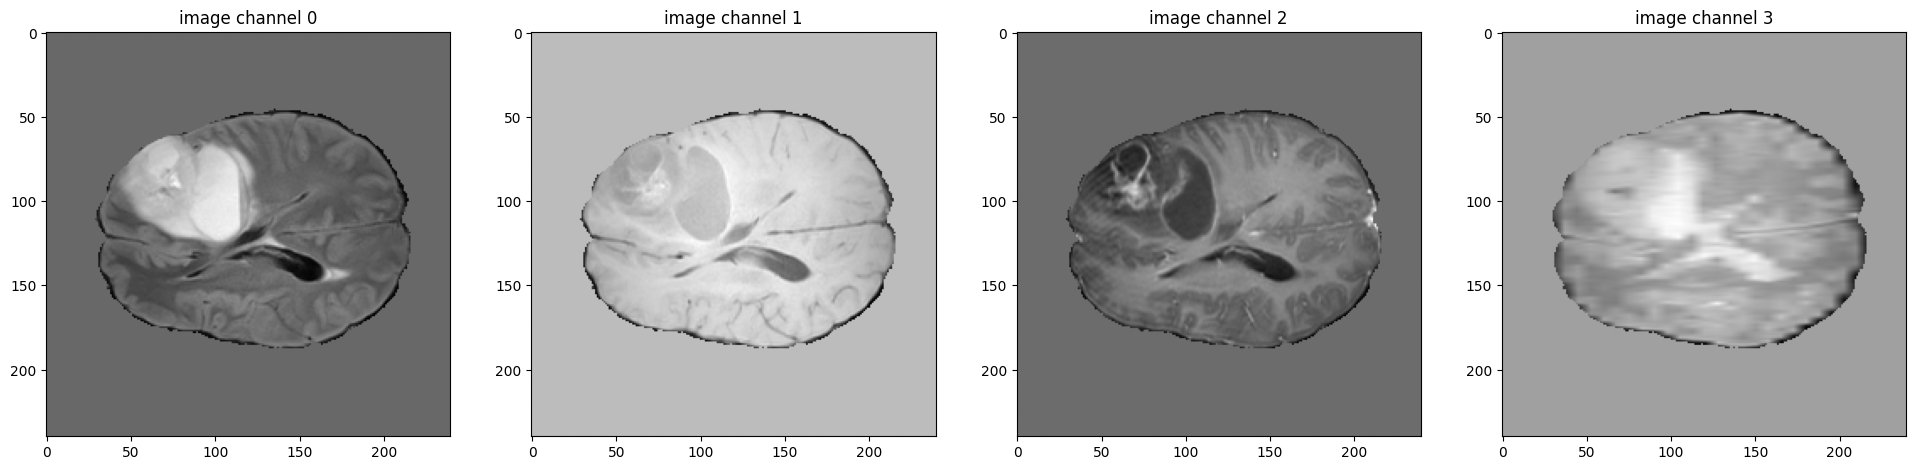

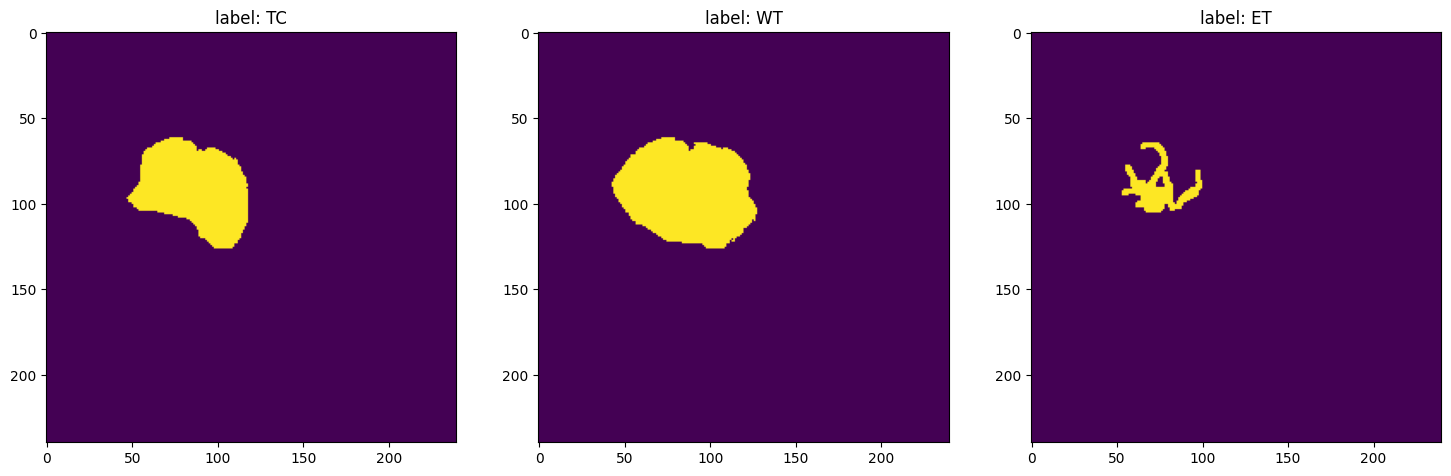

In [27]:
# Pick one sample from validation set to visualise (middle axial slice)
val_sample = val_ds[0]
print(f"image shape: {val_sample['image'].shape}")
print(f"label shape: {val_sample['label'].shape}")

slice_idx = val_sample["image"].shape[3] // 2

plt.figure("image", (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"image channel {i}")
    plt.imshow(val_sample["image"][i, :, :, slice_idx].detach().cpu(), cmap="gray")
plt.show()

plt.figure("label", (18, 6))
channel_names = ["TC", "WT", "ET"]
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label: {channel_names[i]}")
    plt.imshow(val_sample["label"][i, :, :, slice_idx].detach().cpu())
plt.show()

## Create 3D UNet, DiceLoss and Adam optimizer

In [ ]:
max_epochs = 10
val_interval = 1

# Select device: MPS (Apple Silicon), CUDA, or CPU
if torch.cuda.is_available():
    device = torch.device("cuda:0")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")
print(f"Using device: {device}")

# 3D UNet: (4, H, W, D) input -> (3, H, W, D) output
model = UNet(
    spatial_dims=3,
    in_channels=4,
    out_channels=3,
    channels=(16, 32, 64, 128, 256),
    strides=(2, 2, 2, 2),
    num_res_units=2,
    dropout=0.2,
).to(device)

loss_function = DiceLoss(smooth_nr=0, smooth_dr=1e-5, squared_pred=True, to_onehot_y=False, sigmoid=True)
optimizer = torch.optim.AdamW(model.parameters(), 1e-4, weight_decay=1e-5)
lr_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs)

dice_metric = DiceMetric(include_background=True, reduction="mean")
dice_metric_batch = DiceMetric(include_background=True, reduction="mean_batch")

post_trans = Compose([Activations(sigmoid=True), AsDiscrete(threshold=0.5)])

Using device: mps


: 

## Execute a typical PyTorch training process

Validation uses sliding-window inference over the full 3D volume.

In [ ]:
best_metric = -1
best_metric_epoch = -1
best_metrics_epochs_and_time = [[], [], []]
epoch_loss_values = []
metric_values = []
metric_values_tc = []
metric_values_wt = []
metric_values_et = []

save_dir = os.path.normpath(os.path.join(os.getcwd(), "..", "..", "res", "models"))
os.makedirs(save_dir, exist_ok=True)

total_start = time.time()
for epoch in range(max_epochs):
    epoch_start = time.time()
    print("-" * 10)
    print(f"epoch {epoch + 1}/{max_epochs}")
    model.train()
    epoch_loss = 0
    step = 0
    for batch_data in train_loader:
        step_start = time.time()
        step += 1
        inputs, labels = (
            batch_data["image"].to(device),
            batch_data["label"].to(device),
        )
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()
        if step % 50 == 0:
            print(
                f"{step}/{len(train_loader)}"
                f", train_loss: {loss.item():.4f}"
                f", step time: {(time.time() - step_start):.4f}"
            )
    lr_scheduler.step()
    epoch_loss /= step
    epoch_loss_values.append(epoch_loss)
    print(f"epoch {epoch + 1} average loss: {epoch_loss:.4f}")

    if (epoch + 1) % val_interval == 0:
        model.eval()
        with torch.no_grad():
            for val_data in val_loader:
                val_inputs, val_labels = (
                    val_data["image"].to(device),
                    val_data["label"].to(device),
                )
                val_outputs = sliding_window_inference(
                    val_inputs, roi_size=roi_size, sw_batch_size=1,
                    predictor=model, overlap=0.5,
                )
                val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
                dice_metric(y_pred=val_outputs, y=val_labels)
                dice_metric_batch(y_pred=val_outputs, y=val_labels)

            metric = dice_metric.aggregate().item()
            metric_values.append(metric)
            metric_batch = dice_metric_batch.aggregate()
            metric_tc = metric_batch[0].item()
            metric_values_tc.append(metric_tc)
            metric_wt = metric_batch[1].item()
            metric_values_wt.append(metric_wt)
            metric_et = metric_batch[2].item()
            metric_values_et.append(metric_et)
            dice_metric.reset()
            dice_metric_batch.reset()

            if metric > best_metric:
                best_metric = metric
                best_metric_epoch = epoch + 1
                best_metrics_epochs_and_time[0].append(best_metric)
                best_metrics_epochs_and_time[1].append(best_metric_epoch)
                best_metrics_epochs_and_time[2].append(time.time() - total_start)
                torch.save(
                    model.state_dict(),
                    os.path.join(save_dir, "best_metric_model.pth"),
                )
                print("saved new best metric model")
            print(
                f"current epoch: {epoch + 1} current mean dice: {metric:.4f}"
                f" tc: {metric_tc:.4f} wt: {metric_wt:.4f} et: {metric_et:.4f}"
                f"\nbest mean dice: {best_metric:.4f}"
                f" at epoch: {best_metric_epoch}"
            )
    print(f"time consuming of epoch {epoch + 1} is: {(time.time() - epoch_start):.4f}")
total_time = time.time() - total_start

----------
epoch 1/10


In [ ]:
print(f"train completed, best_metric: {best_metric:.4f} at epoch: {best_metric_epoch}, total time: {total_time:.1f}s.")

## Plot the loss and metric

In [ ]:
plt.figure("train", (12, 6))
plt.subplot(1, 2, 1)
plt.title("Epoch Average Loss")
x = [i + 1 for i in range(len(epoch_loss_values))]
y = epoch_loss_values
plt.xlabel("epoch")
plt.plot(x, y, color="red")
plt.subplot(1, 2, 2)
plt.title("Val Mean Dice")
x = [val_interval * (i + 1) for i in range(len(metric_values))]
y = metric_values
plt.xlabel("epoch")
plt.plot(x, y, color="green")
plt.show()

plt.figure("train", (18, 6))
plt.subplot(1, 3, 1)
plt.title("Val Mean Dice TC")
x = [val_interval * (i + 1) for i in range(len(metric_values_tc))]
y = metric_values_tc
plt.xlabel("epoch")
plt.plot(x, y, color="blue")
plt.subplot(1, 3, 2)
plt.title("Val Mean Dice WT")
x = [val_interval * (i + 1) for i in range(len(metric_values_wt))]
y = metric_values_wt
plt.xlabel("epoch")
plt.plot(x, y, color="brown")
plt.subplot(1, 3, 3)
plt.title("Val Mean Dice ET")
x = [val_interval * (i + 1) for i in range(len(metric_values_et))]
y = metric_values_et
plt.xlabel("epoch")
plt.plot(x, y, color="purple")
plt.show()

## Check best model output with input image and label

Display the middle axial slice of predictions alongside ground truth.

In [ ]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_metric_model.pth"), weights_only=True))
model.eval()
with torch.no_grad():
    val_input = val_ds[0]["image"].unsqueeze(0).to(device)
    val_output = sliding_window_inference(
        val_input, roi_size=roi_size, sw_batch_size=1, predictor=model, overlap=0.5,
    )
    val_output = post_trans(val_output[0])

slice_idx = val_ds[0]["image"].shape[3] // 2

plt.figure("image", (24, 6))
for i in range(4):
    plt.subplot(1, 4, i + 1)
    plt.title(f"image channel {i}")
    plt.imshow(val_ds[0]["image"][i, :, :, slice_idx].detach().cpu(), cmap="gray")
plt.show()

plt.figure("label", (18, 6))
channel_names = ["TC", "WT", "ET"]
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"label: {channel_names[i]}")
    plt.imshow(val_ds[0]["label"][i, :, :, slice_idx].detach().cpu())
plt.show()

plt.figure("output", (18, 6))
for i in range(3):
    plt.subplot(1, 3, i + 1)
    plt.title(f"output: {channel_names[i]}")
    plt.imshow(val_output[i, :, :, slice_idx].detach().cpu())
plt.show()

## Final evaluation on validation set

In [ ]:
model.load_state_dict(torch.load(os.path.join(save_dir, "best_metric_model.pth"), weights_only=True))
model.eval()

dice_metric.reset()
dice_metric_batch.reset()

with torch.no_grad():
    for val_data in val_loader:
        val_inputs = val_data["image"].to(device)
        val_labels = val_data["label"].to(device)
        val_outputs = sliding_window_inference(
            val_inputs, roi_size=roi_size, sw_batch_size=1, predictor=model, overlap=0.5,
        )
        val_outputs = [post_trans(i) for i in decollate_batch(val_outputs)]
        dice_metric(y_pred=val_outputs, y=val_labels)
        dice_metric_batch(y_pred=val_outputs, y=val_labels)

    metric_org = dice_metric.aggregate().item()
    metric_batch_org = dice_metric_batch.aggregate()
    dice_metric.reset()
    dice_metric_batch.reset()

metric_tc = metric_batch_org[0].item()
metric_wt = metric_batch_org[1].item()
metric_et = metric_batch_org[2].item()

print(f"Final validation mean Dice: {metric_org:.4f}")
print(f"  TC: {metric_tc:.4f}")
print(f"  WT: {metric_wt:.4f}")
print(f"  ET: {metric_et:.4f}")